In [28]:
# 6-20-2026

In [29]:
import pandas as pd
import numpy as np

In [30]:
df_fires = pd.read_csv("../data/fire_cleaned.csv")

In [31]:
print(df_fires["domain_id"].value_counts())
# 15 real domains with <2k samples. 30k samples not mapped to a domain
# N=34, domain pairs = 1156, non diagonal dimain pairs = 1122
# for training, N=30, pairs = 900, non diagonal = 870

domain_id
 11    650816
 0     571168
 45    351946
 37    275674
 20    204086
 4     187388
 5     170957
 22    138127
 2     121418
 13    112293
 21    102623
 25     90894
 27     62561
 23     52235
 12     46052
 1      43587
 28     38204
 8      35236
 16     31121
 29     30932
-1      29071
 47     28309
 49     20798
 46     20344
 26     18135
 38     17898
 6      16785
 32     13212
 36     11915
 19     10803
 18      9214
 39      7757
 33      6504
 7       5176
 30      2434
 15      1924
 17      1874
 24      1554
 31      1470
 14      1411
 10      1346
 48       805
 9        709
 3        507
 34       331
 35       321
 43       270
 42        99
 40        27
 41         1
Name: count, dtype: int64


In [32]:
df_fires.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3548322 entries, 0 to 3548321
Data columns (total 35 columns):
 #   Column              Dtype  
---  ------              -----  
 0   time                object 
 1   latitude            float64
 2   longitude           float64
 3   gwis_ba_target      float64
 4   domain_id           int64  
 5   area                float64
 6   cams_frpfire        float64
 7   ecoregion           float64
 8   fwi_mean            float64
 9   gwis_ba             float64
 10  gwis_ba_valid_mask  int64  
 11  lccs_class_1        float64
 12  lccs_class_2        float64
 13  lccs_class_3        float64
 14  lccs_class_4        float64
 15  lccs_class_6        float64
 16  lccs_class_7        float64
 17  lsm                 float64
 18  ndvi                float64
 19  pop_dens            float64
 20  pyrome              int64  
 21  rel_hum             float64
 22  skt                 float64
 23  ssr                 float64
 24  ssrd                floa

In [45]:
df_fires[["gwis_ba_target", "gwis_ba"]].describe()

,gwis_ba_target,gwis_ba
count,3.506602e+06,3.506602e+06
mean,1.178141e+03,1.178141e+03
std,3.956371e+03,3.956371e+03
min,5.708795e-09,5.708795e-09
25%,5.123101e+01,5.123101e+01
50%,2.137034e+02,2.137034e+02
75%,7.910970e+02,7.910970e+02
max,7.638605e+04,7.638605e+04


In [33]:
df_fires.isna().sum()

time                      0
latitude                  0
longitude                 0
gwis_ba_target            0
domain_id                 0
area                      0
cams_frpfire              0
ecoregion             29071
fwi_mean                  0
gwis_ba                   0
gwis_ba_valid_mask        0
lccs_class_1              0
lccs_class_2              0
lccs_class_3              0
lccs_class_4              0
lccs_class_6              0
lccs_class_7              0
lsm                       0
ndvi                      0
pop_dens                  0
pyrome                    0
rel_hum                   0
skt                       0
ssr                       0
ssrd                      0
swvl1                     0
swvl2                     0
swvl3                     0
swvl4                     0
t2m_max                   0
t2m_mean                  0
t2m_min                   0
tp                        0
vpd                       0
ws10                      0
dtype: int64

In [34]:
# following domains will be taken out:
# 15, 17, 24, 31, 14, 10, 48, 9, 3, 34, 35, 43, 42, 40, 41
# and -1 (not mapped to domain)

"""
 15      1924
 17      1874
 24      1554
 31      1470
 14      1411
 10      1346
 48       805
 9        709
 3        507
 34       331
 35       321
 43       270
 42        99
 40        27
 41         1
"""

'\n 15      1924\n 17      1874\n 24      1554\n 31      1470\n 14      1411\n 10      1346\n 48       805\n 9        709\n 3        507\n 34       331\n 35       321\n 43       270\n 42        99\n 40        27\n 41         1\n'

In [35]:
domains_to_drop  = [15, 17, 24, 31, 14, 10, 48, 9, 3, 34, 35, 43, 42, 40, 41, -1]

In [36]:
df_fires = df_fires[~df_fires["domain_id"].isin(domains_to_drop)].copy() # drop the 16 domains

<Axes: >

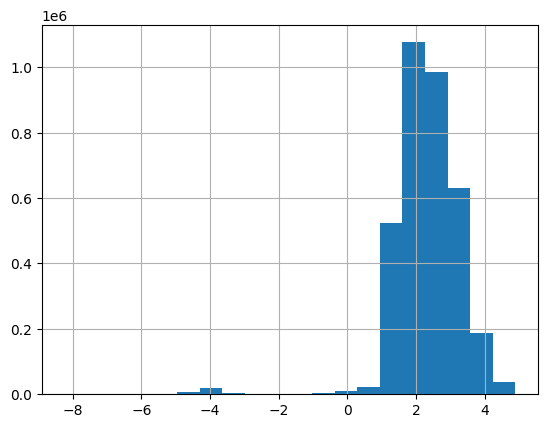

In [37]:
np.log10(df_fires["gwis_ba"]).hist(bins=20)

In [38]:
df_fires["log_ba"] = np.log10(df_fires["gwis_ba"]) # log-scale burned area since power law distribution

<Axes: >

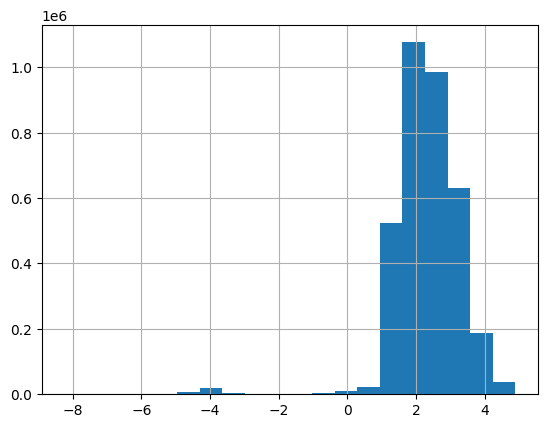

In [43]:
df_fires["log_ba"].hist(bins=20)

In [ ]:
# structure will be domain(scaler, [model1, model2,...], [train_X, train_y, test_X, test_y])
# every domain gets its own scaler, but domain pairs work like: get domain j test data, scale with domain i scaler, feed into domain i model, compare against j test

In [44]:
df_fires.isna().sum()

time                  0
latitude              0
longitude             0
gwis_ba_target        0
domain_id             0
area                  0
cams_frpfire          0
ecoregion             0
fwi_mean              0
gwis_ba               0
gwis_ba_valid_mask    0
lccs_class_1          0
lccs_class_2          0
lccs_class_3          0
lccs_class_4          0
lccs_class_6          0
lccs_class_7          0
lsm                   0
ndvi                  0
pop_dens              0
pyrome                0
rel_hum               0
skt                   0
ssr                   0
ssrd                  0
swvl1                 0
swvl2                 0
swvl3                 0
swvl4                 0
t2m_max               0
t2m_mean              0
t2m_min               0
tp                    0
vpd                   0
ws10                  0
log_ba                0
dtype: int64

In [46]:
(df_fires["gwis_ba"] == df_fires["gwis_ba_target"]).mean()


np.float64(1.0)

In [47]:
df_fires["gwis_ba_valid_mask"].value_counts()


gwis_ba_valid_mask
1    3506602
Name: count, dtype: int64

In [48]:
df_fires[["lccs_class_1","lccs_class_2","lccs_class_3","lccs_class_4","lccs_class_6","lccs_class_7"]].sum(axis=1).describe()

count    3.506602e+06
mean     9.825873e+01
std      5.736698e+00
min      0.000000e+00
25%      9.917284e+01
50%      9.997531e+01
75%      1.000000e+02
max      1.000000e+02
dtype: float64

In [49]:
cols_to_drop = [
    "latitude", "longitude", "time", "pyrome", "ecoregion", "area",
    "cams_frpfire", "gwis_ba_target", "gwis_ba", "gwis_ba_valid_mask"
]
# drop these cols as they won't help for prediction, keep domain for partitioning
df_fires = df_fires.drop(columns=cols_to_drop)

In [51]:
df_fires.columns

Index(['domain_id', 'fwi_mean', 'lccs_class_1', 'lccs_class_2', 'lccs_class_3',
       'lccs_class_4', 'lccs_class_6', 'lccs_class_7', 'lsm', 'ndvi',
       'pop_dens', 'rel_hum', 'skt', 'ssr', 'ssrd', 'swvl1', 'swvl2', 'swvl3',
       'swvl4', 't2m_max', 't2m_mean', 't2m_min', 'tp', 'vpd', 'ws10',
       'log_ba'],
      dtype='object')

In [52]:
output_dir = "domain_csvs"

for domain_id, group in df_fires.groupby("domain_id"):
    group.to_csv(f"{output_dir}/domain_{domain_id}.csv", index=False)

print(f"saved {df_fires['domain_id'].nunique()} domain csvs to {output_dir}/")

saved 34 domain csvs to domain_csvs/
